# EDGE AI FOR EARLY IDENTIFICATION OF A CRITICAL STATUS

## Dataset

The underlying data for this model is sourced from the Kaggle EHR dataset:(https://www.kaggle.com/datasets/vipulshahi/ehr-data). Preprocessing involved isolating three continuous features: heart rate, respiratory rate, and oxygen saturation.

The target feature was engineered to evaluate to True when a minimum of two out of three predefined thresholds are exceeded (Heart Rate ≥ 81, Respiratory Rate ≥ 18, SpO2 ≤ 95). Although these parameters are less restrictive than established medical literature, they are sufficient for the scope of the local device. The local model's primary function is to act as a high-sensitivity threshold monitor to activate the panic mode, effectively offloading more computationally heavy and clinically rigorous analysis to the cloud architecture.

## Data Loading

In [1]:
!pip install pandas

In [2]:
import pandas as pd
df=pd.read_csv("ehr_disease_progression.csv",sep=",")
df.head()

,patient_id,day,bp_systolic,bp_diastolic,heart_rate,respiratory_rate,temperature,oxygen_saturation,med_adherence,symptom_severity,progressed_to_critical
0,1,1,124.386263,78.783509,77.667063,18.584018,98.221668,96.290678,0.623233,4.464705,0
1,1,2,125.783587,77.784802,77.810397,18.674856,98.412589,97.835673,0.623233,4.464705,0
2,1,3,124.337667,79.906399,80.797931,19.243176,98.495145,97.023581,0.623233,4.464705,0
3,1,4,124.366888,80.256118,78.529477,18.728280,98.380768,96.846741,0.623233,4.464705,0
4,1,5,124.433493,79.303151,78.008992,19.240734,98.356411,96.219867,0.623233,4.464705,0


In [3]:
df=df[["heart_rate","respiratory_rate","oxygen_saturation"]]
df.head()

,heart_rate,respiratory_rate,oxygen_saturation
0,77.667063,18.584018,96.290678
1,77.810397,18.674856,97.835673
2,80.797931,19.243176,97.023581
3,78.529477,18.728280,96.846741
4,78.008992,19.240734,96.219867


## Data Processing

In [4]:
df=df.dropna()
HR_THRESHOLD=81
RR_THRESHOLD=18
SPO2_THRESHOLD=95

hr_flag=df['heart_rate'] >= HR_THRESHOLD
rr_flag=df['respiratory_rate'] >= RR_THRESHOLD
spo2_flag=df['oxygen_saturation'] <= SPO2_THRESHOLD

n_criteria=hr_flag.astype(int) + rr_flag.astype(int) + spo2_flag.astype(int)
df['status']=(n_criteria >= 2).astype(int)

CLASS_NAMES=['Stable', 'Critical']
print('Class distribution:')
print(df['status'].value_counts().sort_index()
        .rename(index={0: 'Stable', 1: 'Critical'}))
df.head()



Class distribution:
status
Stable      53699
Critical     6301
Name: count, dtype: int64


,heart_rate,respiratory_rate,oxygen_saturation,status
0,77.667063,18.584018,96.290678,0
1,77.810397,18.674856,97.835673,0
2,80.797931,19.243176,97.023581,0
3,78.529477,18.728280,96.846741,0
4,78.008992,19.240734,96.219867,0


In [5]:

import numpy as np
labels=df.pop('status').to_numpy(dtype='float32')
features=np.array(df)

In [6]:
features

array([[77.66706252, 18.58401829, 96.2906782 ],
       [77.81039663, 18.67485629, 97.83567337],
       [80.79793072, 19.24317622, 97.02358087],
       ...,
       [77.40752606, 19.28074612, 96.76857066],
       [78.27694703, 18.4513394 , 95.8643092 ],
       [76.04026329, 19.62597721, 96.8761295 ]])

In [7]:
labels

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

## Train/test split

In [8]:
from sklearn.model_selection import train_test_split

train_features, test_features, train_labels, test_labels = train_test_split(features, labels, test_size=0.15,shuffle=True,stratify=labels)

## Feature normalization

In [9]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
train_features=scaler.fit_transform(train_features)
test_features=scaler.transform(test_features)
print('=== Copy these constants into vital-signs-panic.c ===')
print(f'static const float FEATURE_MEAN[3]  = '
      f'{{ {scaler.mean_[0]:.4f}f, {scaler.mean_[1]:.4f}f, {scaler.mean_[2]:.4f}f }};  '
      f'/* heart_rate  respiratory_rate  oxygen_saturation */')
print(f'static const float FEATURE_SCALE[3] = '
      f'{{ {scaler.scale_[0]:.4f}f, {scaler.scale_[1]:.4f}f, {scaler.scale_[2]:.4f}f }};')

=== Copy these constants into vital-signs-panic.c ===
static const float FEATURE_MEAN[3]  = { 76.1322f, 16.3496f, 96.5798f };  /* heart_rate  respiratory_rate  oxygen_saturation */
static const float FEATURE_SCALE[3] = { 5.4739f, 2.1311f, 1.3924f };


### Data augumentation

Injecting noise that simulates small errors in sensor measurements prevents the model from memorizing exact programmatic rules, encouraging better generalization to unseen data

In [10]:
rng=np.random.default_rng(42)
noise_std_raw=np.array([2.0,1.5,1.0])
noise_scaled=noise_std_raw/scaler.scale_
train_features_aug = train_features + rng.normal(0, noise_scaled, size=train_features.shape)


## Model

In [11]:
import tensorflow as tf
from tensorflow.keras.layers import Dense,Activation

### Building the model

In [12]:
NB_features=3
model=tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="relu",input_shape=(NB_features,)),
    tf.keras.layers.Dense(16,activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid"),
])
model.compile(optimizer="adam",
              loss=tf.keras.losses.binary_crossentropy,
              metrics=[tf.keras.metrics.Precision(name="precision"),
                       tf.keras.metrics.Recall(name="recall")])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353 (1.38 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

### Training the model

In [13]:
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
class_labels=np.unique(train_labels)
weights=compute_class_weight(class_weight='balanced',classes=class_labels,y=train_labels)
class_weight=dict(zip(class_labels.astype(int), weights))
print('class_weight:',class_weight)
early_stop=EarlyStopping(monitor='val_loss',patience=10,
                           restore_best_weights=True,verbose=1)

history=model.fit(
    x=train_features_aug,
    y=train_labels,
    epochs=150,
    validation_data=(test_features, test_labels),
    callbacks=[early_stop],
    class_weight=class_weight,
    verbose=1,
    shuffle=True
)


class_weight: {np.int64(0): np.float64(0.5586714573656998), np.int64(1): np.float64(4.76101568334578)}
Epoch 1/150
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.3477 - precision: 0.3864 - recall: 0.8454 - val_loss: 0.2223 - val_precision: 0.5354 - val_recall: 0.9693
Epoch 2/150
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 0.2852 - precision: 0.4279 - recall: 0.8919 - val_loss: 0.2235 - val_precision: 0.5076 - val_recall: 0.9873
Epoch 3/150
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2801 - precision: 0.4291 - recall: 0.8958 - val_loss: 0.2125 - val_precision: 0.5247 - val_recall: 0.9894
Epoch 4/150
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2777 - precision: 0.4288 - recall: 0.8938 - val_loss: 0.1822 - val_precision: 0.5853 - val_recall: 0.9915
Epoch 5/150
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.2762 - precision: 0.4288 - recall: 0.8954 - val_loss: 0.1879 - val_precision: 0.5713 - val_recall: 0.9915
Epoch 6/150
1594/1594 ━━━━━━━━━━━━━━━━━━

In [14]:
loss,precision,recall =model.evaluate(test_features,test_labels,
                                          batch_size=32,verbose=1)

f1 = 2 *(precision * recall)/(precision + recall) if (precision+recall) > 0 else 0.0

print(f'Test precision: {precision:.4f}')
print(f'Test recall:    {recall:.4f}')
print(f'Test F1-score:  {f1:.4f}')

282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1581 - precision: 0.6279 - recall: 0.9873
Test precision: 0.6279
Test recall:    0.9873
Test F1-score:  0.7676


### Per-class evaluation

282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

      Stable       1.00      0.93      0.96      8055
    Critical       0.63      0.99      0.77       945

    accuracy                           0.94      9000
   macro avg       0.81      0.96      0.87      9000
weighted avg       0.96      0.94      0.94      9000



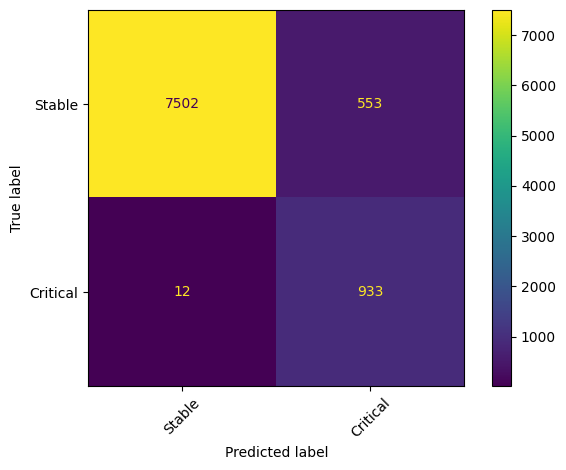

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
y_pred=(model.predict(test_features) >= 0.5).astype(int).ravel()
y_true=test_labels.astype(int)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred,
    display_labels=CLASS_NAMES,
    xticks_rotation=45,
)
plt.tight_layout()


## Converting the model for Iot device

In [16]:
!pip install emlearn

In [17]:
import emlearn
path='vital_signs_panic.h'
cmodel=emlearn.convert(model, method="inline")
cmodel.save(file=path,name="vital_signs_panic")
print("wrote model to",path)

wrote model to vital_signs_panic.h


## Model size vs device constraints


In [18]:
import os

size_bytes    = os.path.getsize(path)
nrf52840_ram  = 256 * 1024  # bytes

print(f'Model file  : {path}')
print(f'File size   : {size_bytes / 1024:.1f} KB ({size_bytes:,} bytes)')
print(f'nRF52840 RAM: {nrf52840_ram // 1024} KB')
print(f'Model uses  : {size_bytes / nrf52840_ram * 100:.1f}% of device RAM')
print()


Model file  : vital_signs_panic.h
File size   : 5.5 KB (5,608 bytes)
nRF52840 RAM: 256 KB
Model uses  : 2.1% of device RAM

